In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, MobileNetV2
from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.optimizers import Adam

In [9]:
import kagglehub

path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


In [10]:
import os

print(os.listdir(path))

['PetImages']


In [11]:
base_dir = os.path.join(path, "PetImages")

print(os.listdir(base_dir))

['Dog', 'Cat']


In [12]:
from PIL import Image

def remove_corrupted_images(path):
    for folder in ["Cat", "Dog"]:
        folder_path = os.path.join(path, folder)
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                os.remove(file_path)

remove_corrupted_images(base_dir)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [14]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [15]:
cnn_model = build_cnn()

history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.6658 - loss: 0.6103 - val_accuracy: 0.7439 - val_loss: 0.5203
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.7569 - loss: 0.5008 - val_accuracy: 0.7773 - val_loss: 0.4648
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - accuracy: 0.8049 - loss: 0.4216 - val_accuracy: 0.8077 - val_loss: 0.4217
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 105ms/step - accuracy: 0.8489 - loss: 0.3430 - val_accuracy: 0.8201 - val_loss: 0.4077
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 103ms/step - accuracy: 0.8891 - loss: 0.2683 - val_accuracy: 0.8247 - val_loss: 0.4113
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 103ms/step - accuracy: 0.9229 - loss: 0.1908 - val_accuracy: 0.8207 - val_loss: 0.4664
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 103ms/step - accuracy: 0.9466 - loss: 0.1369 - val_accuracy: 0.8239 - val_loss: 0.4759
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.9593 - loss: 0

In [16]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

vgg_model = models.Model(inputs=base_model.input, outputs=output)

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_vgg = vgg_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 231ms/step - accuracy: 0.7192 - loss: 0.5646 - val_accuracy: 0.8543 - val_loss: 0.4324
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 223ms/step - accuracy: 0.8523 - loss: 0.3884 - val_accuracy: 0.8828 - val_loss: 0.3272
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 223ms/step - accuracy: 0.8763 - loss: 0.3185 - val_accuracy: 0.8958 - val_loss: 0.2786
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 223ms/step - accuracy: 0.8893 - loss: 0.2815 - val_accuracy: 0.8992 - val_loss: 0.2539
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 223ms/step - accuracy: 0.8985 - loss: 0.2561 - val_accuracy: 0.9106 - val_loss: 0.2337


In [18]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

# 🔥 IMPORTANT CHANGE HERE
resnet_model = models.Model(inputs=base_model.input, outputs=output)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.5709 - loss: 0.6871 - val_accuracy: 0.6202 - val_loss: 0.6548
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.6115 - loss: 0.6570 - val_accuracy: 0.5914 - val_loss: 0.6617
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 114ms/step - accuracy: 0.6176 - loss: 0.6505 - val_accuracy: 0.6319 - val_loss: 0.6421
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.6235 - loss: 0.6479 - val_accuracy: 0.6365 - val_loss: 0.6412
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 117ms/step - accuracy: 0.6308 - loss: 0.6428 - val_accuracy: 0.6429 - val_loss: 0.6358


In [19]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

# 🔥 CHANGE HERE
mobilenet_model = models.Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 🔥 STORE HISTORY ALSO
history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 133ms/step - accuracy: 0.9583 - loss: 0.1119 - val_accuracy: 0.9804 - val_loss: 0.0510
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.9789 - loss: 0.0572 - val_accuracy: 0.9806 - val_loss: 0.0461
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 106ms/step - accuracy: 0.9829 - loss: 0.0478 - val_accuracy: 0.9832 - val_loss: 0.0433
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.9840 - loss: 0.0439 - val_accuracy: 0.9812 - val_loss: 0.0442
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 106ms/step - accuracy: 0.9853 - loss: 0.0405 - val_accuracy: 0.9830 - val_loss: 0.0422


In [22]:
# Step 1: Change image size
img_size_299 = (299, 299)
batch_size = 32

# Step 2: Create NEW generators (don't overwrite old ones)
train_data_299 = datagen.flow_from_directory(
    base_dir,
    target_size=img_size_299,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data_299 = datagen.flow_from_directory(
    base_dir,
    target_size=img_size_299,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# Step 3: Import model
from tensorflow.keras.applications import InceptionV3

# Step 4: Load base model
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(299, 299, 3)
)

# Step 5: Freeze layers
base_model.trainable = False

# Step 6: Add custom layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

# Step 7: Create model
inception_model = models.Model(inputs=base_model.input, outputs=output)

# Step 8: Compile
inception_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 9: Train
history_inception = inception_model.fit(
    train_data_299,
    validation_data=val_data_299,
    epochs=5
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 172ms/step - accuracy: 0.9790 - loss: 0.0718 - val_accuracy: 0.9934 - val_loss: 0.0230
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 178ms/step - accuracy: 0.9924 - loss: 0.0240 - val_accuracy: 0.9934 - val_loss: 0.0213
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 177ms/step - accuracy: 0.9938 - loss: 0.0199 - val_accuracy: 0.9934 - val_loss: 0.0234
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 172ms/step - accuracy: 0.9941 - loss: 0.0180 - val_accuracy: 0.9930 - val_loss: 0.0216
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 161ms/step - accuracy: 0.9945 - loss: 0.0163 - val_accuracy: 0.9940 - val_loss: 0.0221


In [24]:
img_size_224 = (224, 224)

val_data_224 = datagen.flow_from_directory(
    base_dir,
    target_size=img_size_224,
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 4998 images belonging to 2 classes.


In [25]:
results = {}

results["CNN"] = cnn_model.evaluate(val_data_224, verbose=0)[1]
results["VGG16"] = vgg_model.evaluate(val_data_224, verbose=0)[1]
results["ResNet50"] = resnet_model.evaluate(val_data_224, verbose=0)[1]
results["MobileNetV2"] = mobilenet_model.evaluate(val_data_224, verbose=0)[1]

results["InceptionV3"] = inception_model.evaluate(val_data_299, verbose=0)[1]

print(results)

{'CNN': 0.8287314772605896, 'VGG16': 0.9105642437934875, 'ResNet50': 0.6428571343421936, 'MobileNetV2': 0.9829931855201721, 'InceptionV3': 0.9939975738525391}


In [26]:
for model_name, acc in results.items():
    print(f"{model_name} Accuracy: {acc:.4f}")

CNN Accuracy: 0.8287
VGG16 Accuracy: 0.9106
ResNet50 Accuracy: 0.6429
MobileNetV2 Accuracy: 0.9830
InceptionV3 Accuracy: 0.9940


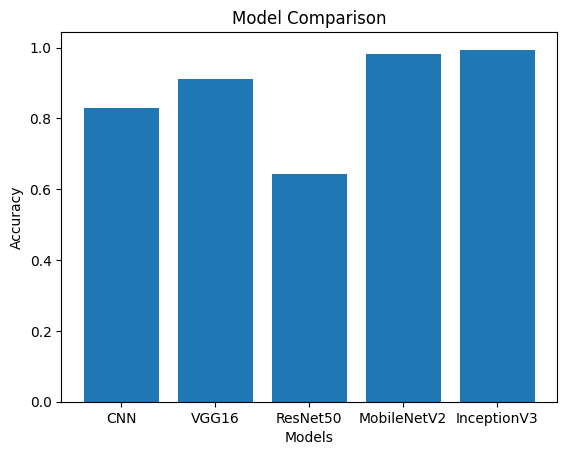

In [27]:
import matplotlib.pyplot as plt

names = list(results.keys())
accuracies = list(results.values())

plt.figure()
plt.bar(names, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [28]:
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: InceptionV3
